In [2]:
from huggingface_hub import notebook_login
notebook_login()

In [4]:
!pip -q install datasets pillow matplotlib requests

import json
import requests
from io import BytesIO

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from datasets import load_dataset

# Load annotations only
ds = load_dataset("jxu124/refcocog", split="train")

print(ds)
print(ds.column_names)

row = ds[0]

# RefCOCOg provides multiple referring expressions for the target object.
phrase = row["sentences"][0]["sent"]
bbox = row["bbox"]  # [x1, y1, x2, y2]

image_info = row["raw_image_info"]
if isinstance(image_info, str):
    image_info = json.loads(image_info)

file_name = image_info["file_name"]
image_url = f"https://images.cocodataset.org/train2014/{file_name}"

print(image_url)

Dataset({
    features: ['image_id', 'split', 'sentences', 'file_name', 'category_id', 'ann_id', 'sent_ids', 'ref_id', 'raw_anns', 'raw_image_info', 'raw_sentences', 'image_path', 'bbox', 'captions', 'global_image_id', 'anns_id'],
    num_rows: 42226
})
['image_id', 'split', 'sentences', 'file_name', 'category_id', 'ann_id', 'sent_ids', 'ref_id', 'raw_anns', 'raw_image_info', 'raw_sentences', 'image_path', 'bbox', 'captions', 'global_image_id', 'anns_id']
https://images.cocodataset.org/train2014/COCO_train2014_000000519404.jpg


Phrase: two woman one in black eatting and the other has a white shirt at the desk
Image: (640, 480)
Ground-truth box: [0.0, 45.95, 238.92, 454.59]


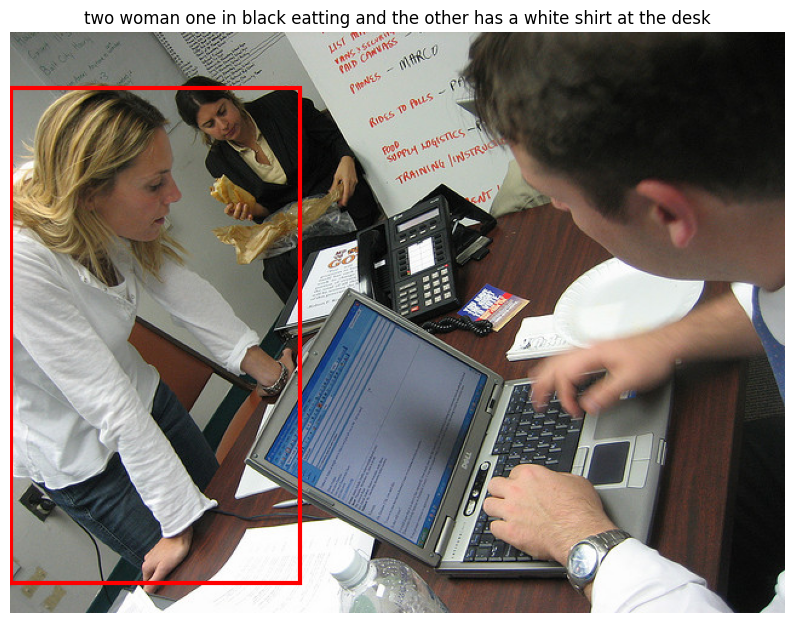

In [5]:
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

response = requests.get(
    image_url,
    verify=False,  # Colab certificate issue for this public COCO host
    timeout=30,
)
response.raise_for_status()

image = Image.open(BytesIO(response.content)).convert("RGB")

print("Phrase:", phrase)
print("Image:", image.size)
print("Ground-truth box:", bbox)

x1, y1, x2, y2 = bbox

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(image)
ax.add_patch(
    patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=3,
        edgecolor="red",
        facecolor="none",
    )
)
ax.set_title(phrase)
ax.axis("off")
plt.show()

In [6]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

/bin/bash: line 1: nvidia-smi: command not found
